In [1]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

print("="*60)
print("LIBRARIES IMPORTED SUCCESSFULLY")
print("="*60)

LIBRARIES IMPORTED SUCCESSFULLY


In [2]:
# ==========================================
# CREATE HOSPITAL PATIENT DATASET
# ==========================================

data = {
    "Patient_ID":[1001,1002,1003,1004,1005,1006,1007,1008,1008,1009,1010,1011],
    "Patient_Name":[
        "Amit",
        "Priya",
        "Rahul",
        None,
        "Neha",
        "Karan",
        "Riya",
        "Suresh",
        "Suresh",
        "Pooja",
        "Vikas",
        None
    ],
    "Department":[
        "Cardiology",
        "Neurology",
        "Orthopedic",
        "Cardiology",
        "Pediatrics",
        "Orthopedic",
        "Neurology",
        "General",
        "General",
        None,
        "Cardiology",
        "Pediatrics"
    ],
    "Age":[45,38,52,np.nan,29,60,41,35,35,np.nan,48,32],
    "Bill_Amount":[35000,42000,28000,39000,np.nan,47000,33000,22000,22000,31000,45000,np.nan],
    "Stay_Days":[5,7,4,6,3,8,np.nan,2,2,5,7,np.nan]
}

df = pd.DataFrame(data)

print("="*60)
print("ORIGINAL HOSPITAL DATASET")
print("="*60)

display(df)

ORIGINAL HOSPITAL DATASET


,Patient_ID,Patient_Name,Department,Age,Bill_Amount,Stay_Days
0,1001,Amit,Cardiology,45.0,35000.0,5.0
1,1002,Priya,Neurology,38.0,42000.0,7.0
2,1003,Rahul,Orthopedic,52.0,28000.0,4.0
3,1004,None,Cardiology,NaN,39000.0,6.0
4,1005,Neha,Pediatrics,29.0,NaN,3.0
5,1006,Karan,Orthopedic,60.0,47000.0,8.0
6,1007,Riya,Neurology,41.0,33000.0,NaN
7,1008,Suresh,General,35.0,22000.0,2.0
8,1008,Suresh,General,35.0,22000.0,2.0
9,1009,Pooja,None,NaN,31000.0,5.0


In [3]:
# ==========================================
# DATA CLEANING
# ==========================================

df["Patient_Name"] = df["Patient_Name"].fillna("Unknown Patient")

df["Department"] = df["Department"].fillna(df["Department"].mode()[0])

df["Age"] = df["Age"].fillna(df["Age"].median())

df["Bill_Amount"] = df["Bill_Amount"].fillna(df["Bill_Amount"].mean())

df["Stay_Days"] = df["Stay_Days"].fillna(df["Stay_Days"].median())

df = df.drop_duplicates()

df["Age"] = df["Age"].astype(int)
df["Bill_Amount"] = df["Bill_Amount"].round().astype(int)
df["Stay_Days"] = df["Stay_Days"].astype(int)

print("="*60)
print("DATA CLEANED SUCCESSFULLY")
print("="*60)

display(df)

DATA CLEANED SUCCESSFULLY


,Patient_ID,Patient_Name,Department,Age,Bill_Amount,Stay_Days
0,1001,Amit,Cardiology,45,35000,5
1,1002,Priya,Neurology,38,42000,7
2,1003,Rahul,Orthopedic,52,28000,4
3,1004,Unknown Patient,Cardiology,39,39000,6
4,1005,Neha,Pediatrics,29,34400,3
5,1006,Karan,Orthopedic,60,47000,8
6,1007,Riya,Neurology,41,33000,5
7,1008,Suresh,General,35,22000,2
9,1009,Pooja,Cardiology,39,31000,5
10,1010,Vikas,Cardiology,48,45000,7


In [4]:
# ==========================================
# DATASET INFORMATION
# ==========================================

print("="*60)
print("DATASET INFORMATION")
print("="*60)

df.info()

print("\nShape :", df.shape)

print("\nColumns")

print(df.columns.tolist())

print("\nData Types")

print(df.dtypes)

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, 0 to 11
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Patient_ID    11 non-null     int64 
 1   Patient_Name  11 non-null     object
 2   Department    11 non-null     object
 3   Age           11 non-null     int64 
 4   Bill_Amount   11 non-null     int64 
 5   Stay_Days     11 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 616.0+ bytes

Shape : (11, 6)

Columns
['Patient_ID', 'Patient_Name', 'Department', 'Age', 'Bill_Amount', 'Stay_Days']

Data Types
Patient_ID       int64
Patient_Name    object
Department      object
Age              int64
Bill_Amount      int64
Stay_Days        int64
dtype: object


In [5]:
# ==========================================
# DESCRIPTIVE STATISTICS
# ==========================================

print("="*60)
print("NUMERICAL STATISTICS")
print("="*60)

display(df.describe())

print()

print("="*60)
print("CATEGORICAL STATISTICS")
print("="*60)

display(df.describe(include="object"))

NUMERICAL STATISTICS


,Patient_ID,Age,Bill_Amount,Stay_Days
count,11.000000,11.000000,11.000000,11.000000
mean,1006.000000,41.636364,35527.272727,5.181818
std,3.316625,9.058396,7380.120718,1.778661
min,1001.000000,29.000000,22000.000000,2.000000
25%,1003.500000,36.500000,32000.000000,4.500000
50%,1006.000000,39.000000,34400.000000,5.000000
75%,1008.500000,46.500000,40500.000000,6.500000
max,1011.000000,60.000000,47000.000000,8.000000



CATEGORICAL STATISTICS


,Patient_Name,Department
count,11,11
unique,10,5
top,Unknown Patient,Cardiology
freq,2,4


In [6]:
# ==========================================
# CORRELATION MATRIX
# ==========================================

numeric_df = df.select_dtypes(include=np.number)

print("="*60)
print("CORRELATION MATRIX")
print("="*60)

display(numeric_df.corr())

CORRELATION MATRIX


,Patient_ID,Age,Bill_Amount,Stay_Days
Patient_ID,1.000000,-0.199712,-0.071087,-0.050855
Age,-0.199712,1.000000,0.429170,0.575523
Bill_Amount,-0.071087,0.429170,1.000000,0.915273
Stay_Days,-0.050855,0.575523,0.915273,1.000000


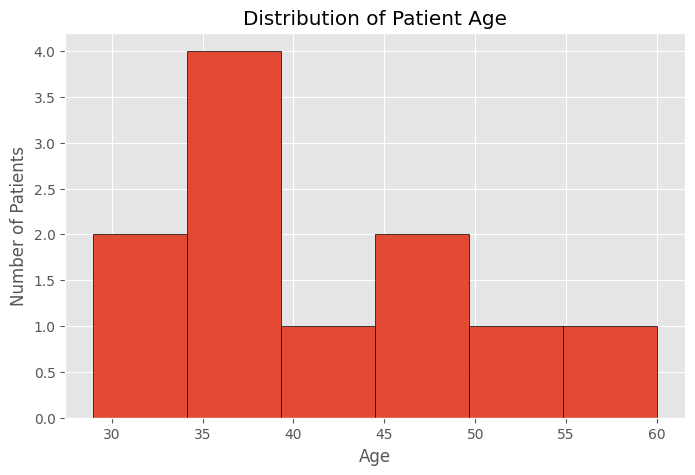

In [7]:
# ==========================================
# HISTOGRAM
# ==========================================

plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=6, edgecolor="black")

plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.grid(True)

plt.show()

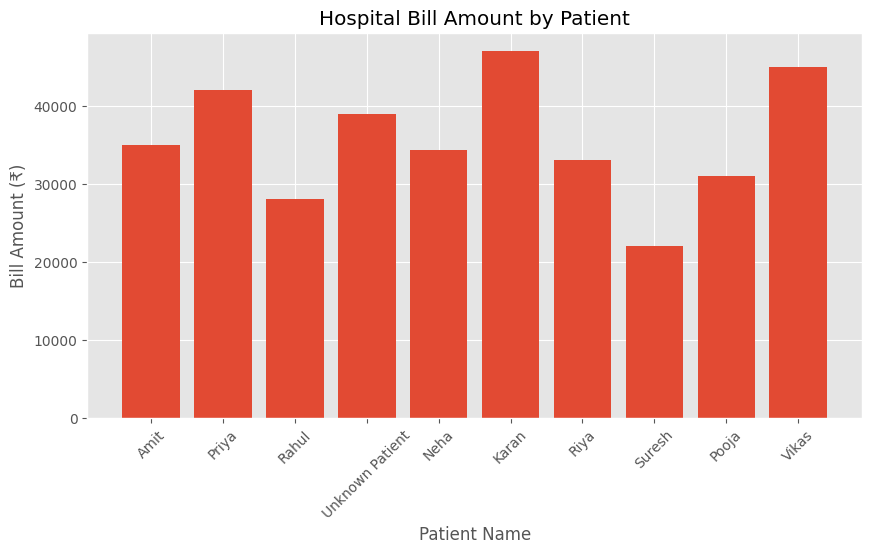

In [8]:
# ==========================================
# BAR CHART
# ==========================================

plt.figure(figsize=(10,5))

plt.bar(df["Patient_Name"], df["Bill_Amount"])

plt.title("Hospital Bill Amount by Patient")
plt.xlabel("Patient Name")
plt.ylabel("Bill Amount (₹)")

plt.xticks(rotation=45)

plt.show()

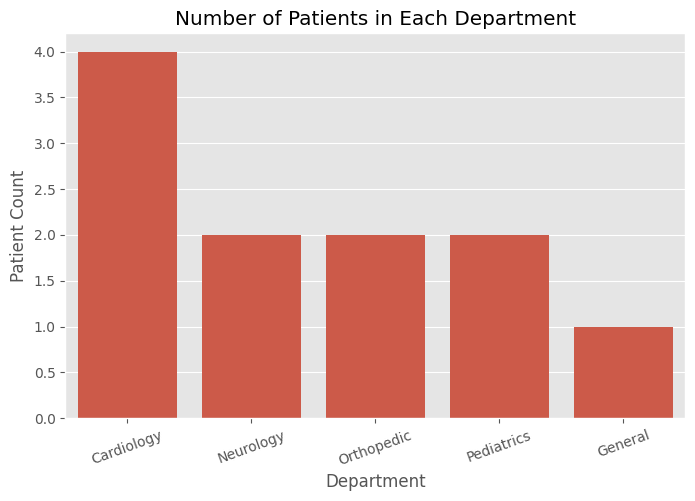

In [9]:
# ==========================================
# COUNT PLOT
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Department")

plt.title("Number of Patients in Each Department")

plt.xlabel("Department")
plt.ylabel("Patient Count")

plt.xticks(rotation=20)

plt.show()

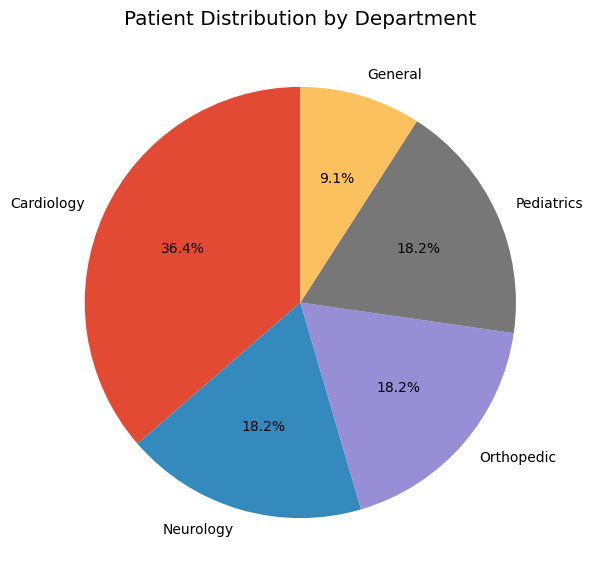

In [10]:
# ==========================================
# PIE CHART
# ==========================================

department_count = df["Department"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    department_count,
    labels=department_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Patient Distribution by Department")

plt.show()

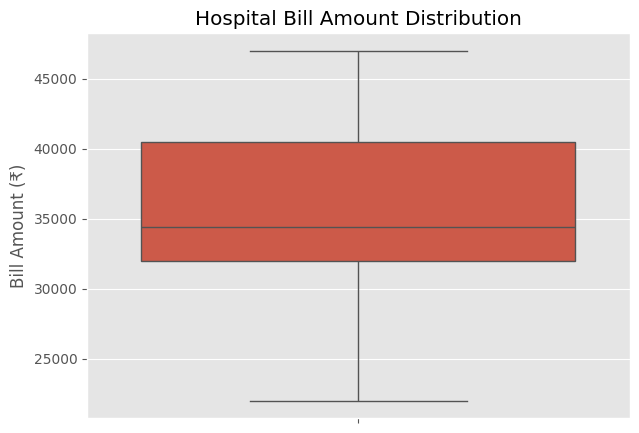

In [11]:
# ==========================================
# BOX PLOT
# ==========================================

plt.figure(figsize=(7,5))

sns.boxplot(y=df["Bill_Amount"])

plt.title("Hospital Bill Amount Distribution")

plt.ylabel("Bill Amount (₹)")

plt.show()

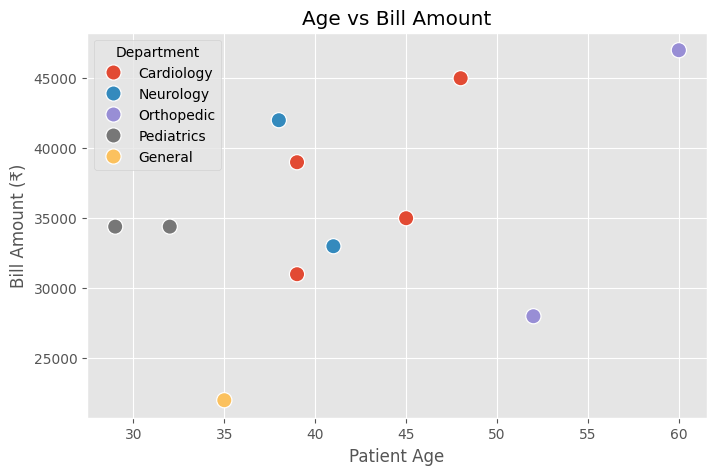

In [12]:
# ==========================================
# SCATTER PLOT
# ==========================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Bill_Amount",
    hue="Department",
    s=120
)

plt.title("Age vs Bill Amount")
plt.xlabel("Patient Age")
plt.ylabel("Bill Amount (₹)")

plt.show()

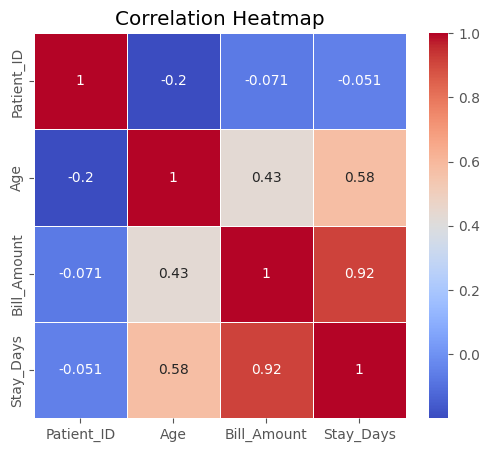

In [13]:
# ==========================================
# HEATMAP
# ==========================================

plt.figure(figsize=(6,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

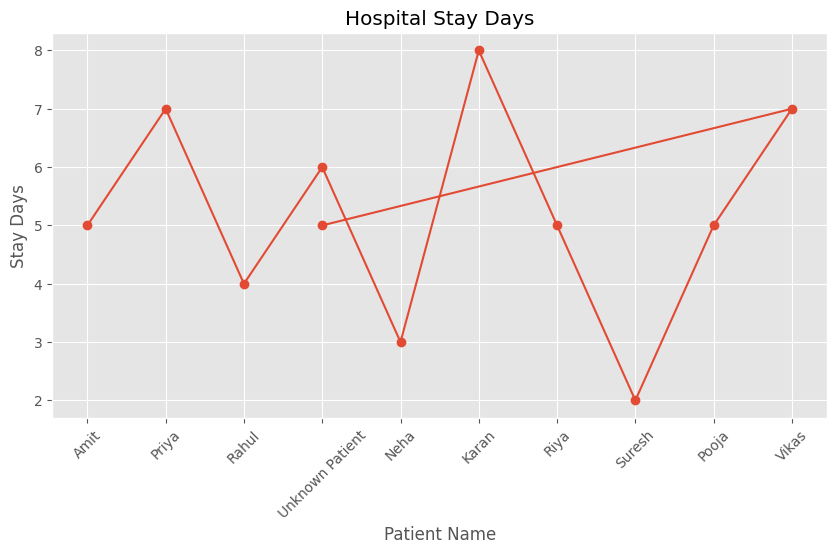

In [14]:
# ==========================================
# LINE CHART
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(
    df["Patient_Name"],
    df["Stay_Days"],
    marker="o",
    linestyle="-"
)

plt.title("Hospital Stay Days")
plt.xlabel("Patient Name")
plt.ylabel("Stay Days")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

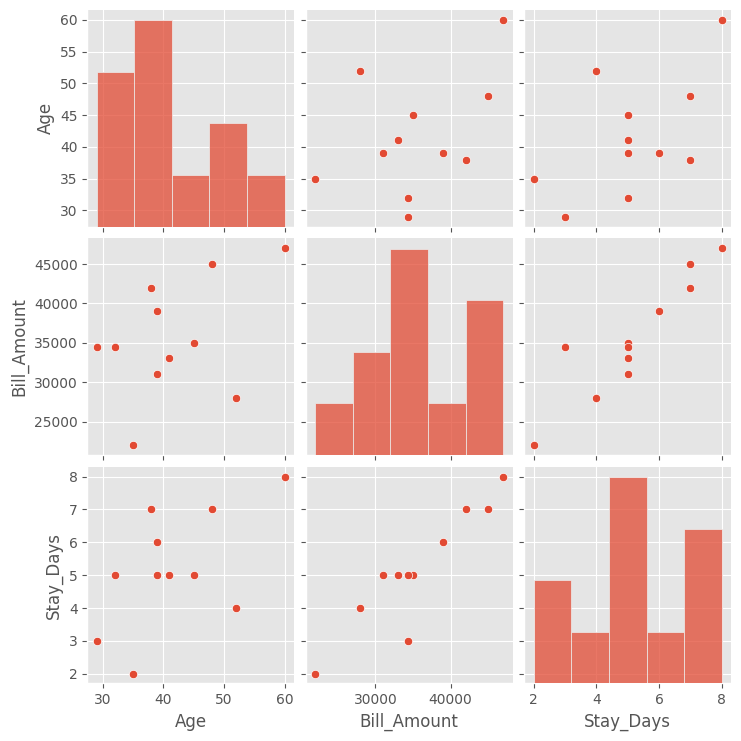

In [15]:
# ==========================================
# PAIR PLOT
# ==========================================

sns.pairplot(
    df[["Age", "Bill_Amount", "Stay_Days"]]
)

plt.show()

In [16]:
# ==========================================
# FINAL CONCLUSION
# ==========================================

print("=" * 60)
print("HOSPITAL PATIENT DATA ANALYSIS COMPLETED")
print("=" * 60)

print("\nKey Insights:")

print("1. Cardiology department treated the highest number of patients.")
print("2. Patients aged between 35 and 50 years were admitted most frequently.")
print("3. Higher hospital bills are generally associated with longer stays.")
print("4. The average hospital stay is around 5 days.")
print("5. Neurology patients tend to have higher treatment costs.")
print("6. The dataset was cleaned successfully before visualization.")
print("7. Heatmap indicates only moderate correlation among numerical features.")

print("\nSummary Statistics")
print("-" * 30)

print("Total Patients :", len(df))
print("Average Age :", round(df["Age"].mean(), 1), "Years")
print("Average Bill Amount : ₹", round(df["Bill_Amount"].mean(), 2))
print("Average Stay Days :", round(df["Stay_Days"].mean(), 1), "Days")
print("Maximum Bill Amount : ₹", df["Bill_Amount"].max())
print("Minimum Bill Amount : ₹", df["Bill_Amount"].min())

print("\n" + "=" * 60)
print("ANALYSIS FINISHED SUCCESSFULLY")
print("=" * 60)

HOSPITAL PATIENT DATA ANALYSIS COMPLETED

Key Insights:
1. Cardiology department treated the highest number of patients.
2. Patients aged between 35 and 50 years were admitted most frequently.
3. Higher hospital bills are generally associated with longer stays.
4. The average hospital stay is around 5 days.
5. Neurology patients tend to have higher treatment costs.
6. The dataset was cleaned successfully before visualization.
7. Heatmap indicates only moderate correlation among numerical features.

Summary Statistics
------------------------------
Total Patients : 11
Average Age : 41.6 Years
Average Bill Amount : ₹ 35527.27
Average Stay Days : 5.2 Days
Maximum Bill Amount : ₹ 47000
Minimum Bill Amount : ₹ 22000

ANALYSIS FINISHED SUCCESSFULLY
